In [1]:
import os
import tempfile
import anndata as ad
import numpy as np
import scanpy as sc
import scvi
import torch

import muon as mu
from muon import MuData

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

#Set working directory
os.chdir('/storage1/fs1/jmillman/Active/DigitalTwin')

/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

Last run with scvi-tools version: 1.3.2


# Load Data

In [2]:
# load rna data
adata_rna = scvi.data.read_h5ad('checkpoints/rna.h5ad')
adata_rna.var['modality'] = "Gene Expression"

In [3]:
adata_rna.obs['dataset'].value_counts().to_csv('rna_datasets.csv')
adata_rna.obs['dataset'].value_counts()

dataset
Multiome_s2d1        18078
Punn_ESC_S6D14       14259
zhu.sn.d32           13157
Punn_scislet3        12621
zhu.sn.d39           12093
Multiome_s6d14       11014
zhu.sn.d21           10500
Punn_scislet1         9700
Multiome_s6d7         9668
zhu.d11               9520
zhu.d14               8598
Punn_scislet2         8534
Punn_scisletw3        8417
Multiome_s5d1         8037
Veres_s3x1            7975
Multiome_s5d5         7904
Multiome_s6d1         7277
Veres_s4x1            6955
weng.s4               6948
Multiome_s4d2         6947
Multiome_s5d3         6531
Punn_scisletw4        6498
hua.d26               5962
Multiome_s3d1         5375
Veres_s3x2            5370
Veres_s6x1            5051
weng.s2d3b            5046
Weng_s3               5010
Veres_s4x2            4981
weng.s5b              4650
zhu.d39               4491
Weng_s2d3a            4434
Balboa_S7w0_A11       4275
Veres_s5x1            4164
Weng_s2d1             4149
Balboa_S7w0_B3        4034
Punn_iPSC_S6D14     

In [4]:
# split gene expression and multiome cells
rna_paired = adata_rna[adata_rna.obs["modality"] == "paired"]
adata_rna = adata_rna[adata_rna.obs["modality"] == "expression"]
adata_rna.shape

(206974, 35462)

In [5]:
# load atac data
adata_atac = scvi.data.read_h5ad('checkpoints/atac.h5ad')
adata_atac.var['modality'] = "Peaks"

In [6]:
adata_atac.obs['dataset'].value_counts().to_csv('atac_datasets.csv')
adata_atac.obs['dataset'].value_counts()

dataset
zhu.d21           37210
zhu.d11           24331
Multiome_s2d1     15881
Multiome_s6d14    12162
Punn_scislet3     12162
zhu.d32           10176
Punn_scislet1     10009
Punn_scislet2      8799
Multiome_s6d7      8771
zhu.d14            8685
Multiome_s5d5      8486
Punn_scisletw3     8161
zhu.d39            7525
Multiome_s5d1      7093
Multiome_s6d1      6597
Multiome_s4d2      6126
Punn_scisletw4     6108
Multiome_s5d3      5821
Multiome_s3d1      4949
Name: count, dtype: int64

In [7]:
# split atac and multiome cells
atac_paired = adata_atac[adata_atac.obs["modality"] == "paired"]
adata_atac = adata_atac[adata_atac.obs["modality"] == "accessibility"]
adata_atac.shape

(87927, 569068)

In [8]:
# create anndata object with multiome cells
common_idx = list(set(rna_paired.obs_names).intersection(set(atac_paired.obs_names)))
rna_paired = rna_paired[common_idx].copy()
atac_paired = atac_paired[common_idx].copy()

adata_paired = ad.concat([rna_paired.copy().T, atac_paired.copy().T]).T
adata_paired.obs = adata_paired.obs.join(rna_paired.obs[['modality','dataset','protocol','stage','day','cellsource']])

In [9]:
adata_paired.obs['dataset'].value_counts().to_csv('multiome_datasets.csv')
adata_paired.obs['dataset'].value_counts()

dataset
Multiome_s2d1     13237
Punn_scislet3     11092
Multiome_s6d14     9671
Punn_scislet1      8729
Multiome_s6d7      8089
Punn_scislet2      7688
Punn_scisletw3     7089
Multiome_s5d1      6944
Multiome_s5d5      6759
Multiome_s6d1      6224
Multiome_s4d2      5698
Punn_scisletw4     5468
Multiome_s5d3      5440
Multiome_s3d1      4490
Name: count, dtype: int64

In [10]:
del rna_paired
del atac_paired

In [11]:
# Use the organizing method from scvi to concatenate anndata objects
adata_mvi = scvi.data.organize_multiome_anndatas(adata_paired, adata_rna, adata_atac)
adata_mvi.obs

del adata_paired
del adata_rna
del adata_atac

/opt/conda/lib/python3.10/site-packages/scvi/data/_preprocessing.py:334: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  return multi_anndata.concatenate(other, join="outer", batch_key=modality_key)
/opt/conda/lib/python3.10/site-packages/scvi/data/_preprocessing.py:334: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  return multi_anndata.concatenate(other, join="outer", batch_key=modality_key)
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f26a444aad0>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/ipker

In [ ]:
adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
adata_mvi.var

In [ ]:
# filter features to remove those that appear in fewer than 1% of the cells
print(adata_mvi.shape)
sc.pp.filter_genes(adata_mvi, min_cells=int(adata_mvi.shape[0] * 0.01))
print(adata_mvi.shape)

In [ ]:
adata_mvi.write('checkpoints/mvi_adata.h5ad')

In [ ]:
adata_mvi

In [ ]:
adata_mvi.obs['dataset'].value_counts().to_csv('DT_datasets.csv')
adata_mvi.obs['dataset'].value_counts()

# Setup and Training MultiVI

In [ ]:
scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="modality",categorical_covariate_keys=["dataset"])

In [ ]:
model = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
    modality_weights="cell",
    n_latent=50,
    n_layers_encoder=3,n_layers_decoder=3, 
)

model.view_anndata_setup()

In [ ]:
model.train()

/tmp/814268.tmpdir/ipykernel_2434/1676823408.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader`

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
# Save MultiVI Model
model_dir = os.path.join('/storage1/fs1/jmillman/Active/DigitalTwin/checkpoints/models', "multivimodel_datasetcovariate_nlatent50")
model.save(model_dir, overwrite=True)

# Calculate latent embedding UMAP

In [2]:
adata_mvi = scvi.data.read_h5ad('checkpoints/mvi_adata.h5ad')
adata_mvi

AnnData object with n_obs × n_vars = 393001 × 94092
    obs: 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender'
    var: 'modality', 'n_cells'
    obsm: 'X_harmony', 'X_integrated_lsi', 'X_pca', 'X_umap.harmony', 'X_umap.integrated.atac', 'X_umap.merged.rna'

In [3]:
model_dir = os.path.join('/storage1/fs1/jmillman/Active/DigitalTwin/checkpoints/models', "multivimodel_datasetcovariate_nlatent50")
model = scvi.model.MULTIVI.load(model_dir, adata=adata_mvi)

INFO     File                                                                                                      
         /storage1/fs1/jmillman/Active/DigitalTwin/checkpoints/models/multivimodel_datasetcovariate_nlatent50/model
         .pt already downloaded                                                                                    


/opt/conda/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [4]:
adata_mvi.obsm["X_multiVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mvi, use_rep="X_multiVI")

In [5]:
sc.tl.umap(adata_mvi)

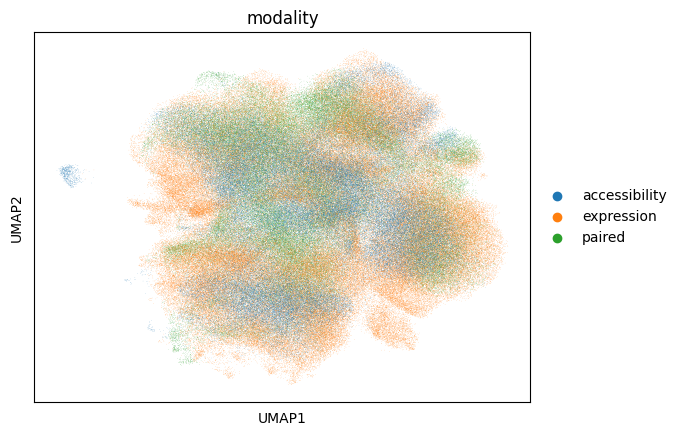

In [6]:
sc.pl.umap(adata_mvi, color="modality")

In [7]:
adata_mvi.write('checkpoints/DT_MultiVIintegrated.h5ad')

In [8]:
adata_rna = adata_mvi[:, adata_mvi.var['modality'] == 'Gene Expression']
adata_rna

View of AnnData object with n_obs × n_vars = 393001 × 16927
    obs: 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'modality', 'n_cells'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
    obsm: 'X_harmony', 'X_integrated_lsi', 'X_pca', 'X_umap.harmony', 'X_umap.integrated.atac', 'X_umap.merged.rna', '_scvi_extra_categorical_covs', 'X_multiVI', 'X_umap'
    obsp: 'distances', 'connectivities'

In [9]:
adata_atac = adata_mvi[:, adata_mvi.var['modality'] == 'Peaks']
adata_atac

View of AnnData object with n_obs × n_vars = 393001 × 77165
    obs: 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'modality', 'n_cells'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
    obsm: 'X_harmony', 'X_integrated_lsi', 'X_pca', 'X_umap.harmony', 'X_umap.integrated.atac', 'X_umap.merged.rna', '_scvi_extra_categorical_covs', 'X_multiVI', 'X_umap'
    obsp: 'distances', 'connectivities'

In [10]:
mdata = MuData({"RNA": adata_rna, "ATAC": adata_atac})
mdata

/opt/conda/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 393001 × 94092
  var:	'modality', 'n_cells'
  2 modalities
    RNA:	393001 x 16927
      obs:	'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels'
      var:	'modality', 'n_cells'
      uns:	'_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
      obsm:	'X_harmony', 'X_integrated_lsi', 'X_pca', 'X_umap.harmony', 'X_umap.integrated.atac', 'X_umap.merged.rna', '_scvi_extra_categorical_covs', 'X_multiVI', 'X_umap'
      obsp:	'distances', 'connectivities'
    ATAC:	393001 x 77165
      obs:	'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels'
      var:	'modality', 'n_cells'
      uns:	'_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
      obsm:	'X_harmony', 'X_integrated_lsi', 'X_pca', 'X_umap.harmony', 'X_umap.integrated.atac', 'X_umap.merged.rna', '_scvi_extra_categorical_covs', 'X_multiVI', 'X_umap'
      obsp:	'distances', 'connectivities'

In [11]:
mdata.write('checkpoints/DT_muon.h5mu')

/opt/conda/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
